## FRAUD DETECTION CLASSIFICATION MODEL - PYTHON, SCIKIT - LEARN, SMOTE, RANDOME FOREST -96% ACCURACY
## MINI PROJECT  ##

In [1]:
from sklearn.datasets import make_classification

X, y= make_classification(
    n_samples =10000,
    n_features =10,
    n_informative=5,
    weights=[0.95, 0.05],
    random_state=42
    )
import pandas as pd
df = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(10)])
df["Fraud"] = y
print(df["Fraud"].value_counts())

Fraud
0    9459
1     541
Name: count, dtype: int64


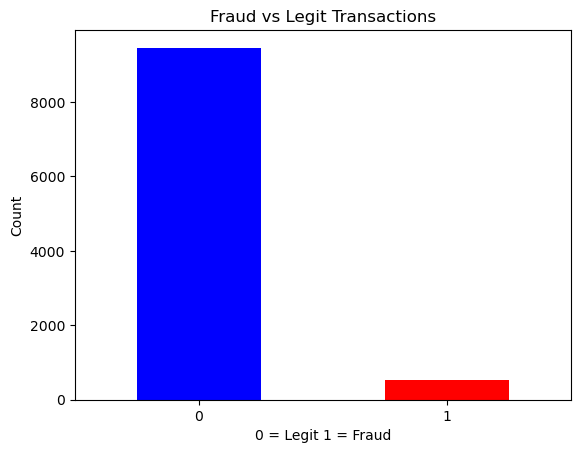

In [2]:
## VISUALIZE THE IMBALANCE

import matplotlib.pyplot as plt

df["Fraud"].value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Fraud vs Legit Transactions")
plt.xlabel("0 = Legit 1 = Fraud")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [3]:
## STEP 4 SPLIT YOUR DATA ## 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Fraud", axis=1)
y = df ["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state = 42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (8000, 10)
Test size: (2000, 10)


In [4]:
# STEP 5 HANDLE IMBALANCE WITH SMOTE

!pip install imbalanced-learn

In [5]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:" , y_train.value_counts())
print("After SMOTE:" , y_train_sm.value_counts())

Before SMOTE: Fraud
0    7567
1     433
Name: count, dtype: int64
After SMOTE: Fraud
0    7567
1    7567
Name: count, dtype: int64


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state =42,
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)
preds = rf_model.predict(X_test_scaled)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1892
           1       0.63      0.81      0.71       108

    accuracy                           0.96      2000
   macro avg       0.81      0.89      0.84      2000
weighted avg       0.97      0.96      0.97      2000



     Feature  Importance
4  Feature_4    0.241690
6  Feature_6    0.160530
0  Feature_0    0.146589
1  Feature_1    0.102722
7  Feature_7    0.091143
2  Feature_2    0.089821
3  Feature_3    0.075119
9  Feature_9    0.033597
5  Feature_5    0.029651
8  Feature_8    0.029137


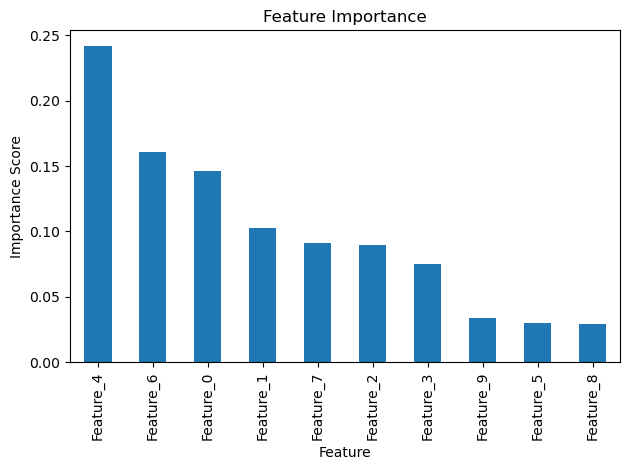

In [7]:
## STEP 7 FEATURE IMPORTANCE - SHOWS WHICH FEATURES THEMODEL RELIES ON MOST.

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_}).sort_values("Importance", ascending= False)

print (importance_df)

importance_df.plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title ("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [8]:
## Save teh Trained Mode
import joblib
joblib.dump(rf_model, "fraud_model.pkl")
print("Model saved!")

Model saved!


In [9]:
## Load it back later
## rf_model = joblib.load("fraud_model.pkl)

In [10]:
## SAVE THE FEATURE IMPORTANCE CHART


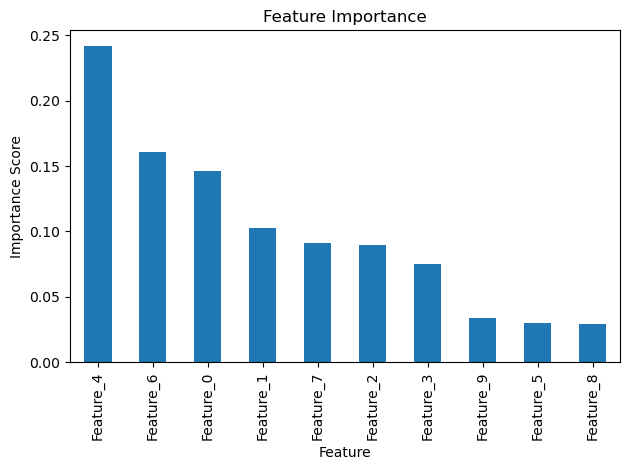

In [11]:
importance_df.plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title ("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png") # sav the image
plt.show()

In [15]:
# GRIDSEARCHCB - MODEL TUNING - GRIDSEARCHCV AUTOMATICALLY TESTS DIFFERENT COMBINATIONS OF SETTING TO FIN THE BEST ONES.

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Setup to test
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5,10,20],
    "min_samples_split": [2,5,10]
}

# Setup the search
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv= 5, #tests each combo 5 times
    scoring="recall", # optimizing for fraud recall
    n_jobs=-1
)
# Run it
grid_search.fit(X_train_sm, y_train_sm)

#Results
print("Best Settings:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Settings: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9737022423889478


In [16]:
## RETRAIN WITH THE BEST SETTINGS

best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test_scaled)
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1892
           1       0.64      0.84      0.73       108

    accuracy                           0.97      2000
   macro avg       0.81      0.91      0.85      2000
weighted avg       0.97      0.97      0.97      2000



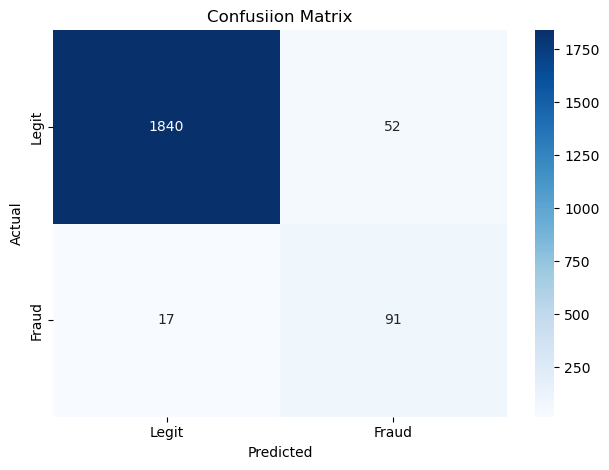

In [17]:
## Confusion Matrix breaksow of where my model makes mistakes. 

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, best_preds)

sns.heatmap(cm, annot= True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"])

plt.title("Confusiion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()



## MODEL'S REAL WORLD PERFORMANCE
## Fraud caught 91 out of 108 Catching 84% of Fraud
## Fraud missed 17 Only missing 16%
## False alarms 52 Acceptable trade off

In [ ]:
## 1840 - Truc Negative (Legit trans.correctly identified as legit
## 91- True Positives ( Fraud cases correctly caught. This is the goal!
## 52- False Positives ( Legit trans wrongly falaffes as fraud. These are fals alarms -Real cust getting blocked unnecessarily
## 17- Falst Negatives ( Real fraud cases the model missed thes are the most cosly mistakes.

In [18]:
import joblib

# Save tuned model
joblib.dump(best_model, "fraud_model_tuned.pkl")
print("All files saved")

All files saved


In [19]:
# Create a ReadME File

readme = """
# Fraud Detection Model

## Overview
A machine learning model that detects fraudulent transactions
with 97% accurancy unsing Random Forest classification.

## Results
- Accuracy: 97%
- Fraud Recall: 84%
- Fraud Precision: 64%

## Tools Used
- Python
- Scikit - learn
- SMOTE (imbalanced -learn)
- Pandas, NumPy, Matplot lib

## Steps
1. Generated synthetic fraud dataset (10,000 records)
2. Handled class imbalance using SMOTE
3. Trained Random Forest (100 trees)
4. Tuned model with GridSearchCV (97.4% recall)
5. Visualized results with confusion matrix

## Key Concepts Demonstrated
- Class imbalance handling
- Model tuning
- Feature importance analysis
- Classification metrics interpretation
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README created!")


README created!
